<a href="https://colab.research.google.com/github/unclesam243/reinforcement_learning_online_msds/blob/main/01_rl_fundamentals/lab_cart_pole1_basics_and_simple_policy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab: Cart Pole using OpenAI gym
## RL Basics and Simple Policy

### University of Virginia
### Reinforcement Learning
#### Last updated: May 11, 2026

---


#### Instructions:  

Carefully read the notes below and run the provided code. Answer each question clearly and show all results.

#### TOTAL POINTS: 10

---

### Agent and Environment

It is essential for the agent to have a way to get the next state and reward from the environment.

Sometimes it is possible for the agent to interact with environment in real life, but often this is expensive / dangerous / impossible.

We use models and simulators in this latter case.

For this reason, the Gym package is useful in RL

**Note**: Going forward, the fork [gymnasium](https://gymnasium.farama.org/) will maintain OpenAI gym.  
We will be using `gymnasium` but will still refer to the environment as `gym` when it doesn't cause confusion.

---

### Introduction to Gym

Gym is a toolkit for developing and comparing RL algorithms.

It comes with many pre-built environments which have functionality to emulate physical environments.


---

### Cart Pole Problem

The **CartPole** problem has a small state space and action space, so it's popular for illustrating ideas.

Pole is attached to a cart on a frictionless track.

Pole starts upright

**Goal** is to keep pole from falling over

Control system by applying **force** -1 or +1 to cart.

**Reward** of +1 for each timestep the pole remains upright

**Episode** ends when pole is more than 12 degrees from vertical, or cart moves more than 2.4 units from center

CartPole-v1 defines *solving* as getting average reward of 195.0 over 100 consecutive trials.

<img src="https://github.com/unclesam243/reinforcement_learning_online_msds/blob/main/01_rl_fundamentals/cartpole.png?raw=1" alt="drawing" width="150"/>

---

### Setup and First Steps

This notebook can be easily run on [Google Colab](https://colab.research.google.com/)

In [1]:
! pip install gymnasium

We can use [renderlab](https://github.com/ryanrudes/renderlab/tree/main) to visualize *results*

In [2]:
! pip install renderlab

In [3]:
import gymnasium as gym
import renderlab as rl

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



Load the environment

In [4]:
env = gym.make("CartPole-v1", render_mode = "rgb_array")

state = env.reset(seed=314)
print(state)

(array([0.04225422, 0.02126478, 0.02520455, 0.00700802], dtype=float32), {})


Given the state, we take an action. The next state comes from the environment, which is encoded in `gym`.

The first element holds components:   
[0]: cart horizontal position (0.0 = center)  
[1]: velocity (positive means right)  
[2]: angle of the pole (0.0 = vertical)  
[3]: pole's angular velocity (positive means clockwise)

In [5]:
# state space number of components
env.observation_space.shape[0]

4

The action space consists of two options:

[0]: move cart left   
[1]: move cart right

In [6]:
env.action_space

Discrete(2)

Let's take an action, draw a sample and look at the results.

In [7]:
# move right
action = 1

# take a step and get next state, reward from environment
state, reward, terminated, truncated, info = env.step(action)
done = terminated or truncated

print('state', state)
print('reward', reward)
print('done', done)
print('info', info)

state [ 0.04267951  0.21601637  0.02534471 -0.27761722]
reward 1.0
done False
info {}


**Note about DONE**  
We need to understand if the episode is done after taking action  

The API now gives more detail on this variable, which may reach `done` state for two reasons:  
- **terminated**=True if environment terminates (eg. due to task completion, failure etc.)  
- **truncated**=True if episode truncates due to a time limit or a reason that is not defined as part of the task MDP.

**Run several steps by taking random actions**  

In [8]:
state = env.reset(seed=314)
for _ in range(5):
    print(env.step(env.action_space.sample())) # take a random action

(array([ 0.04267951, -0.1742094 ,  0.02534471,  0.30753553], dtype=float32), 1.0, False, False, {})
(array([0.03919533, 0.02054241, 0.03149542, 0.02295217], dtype=float32), 1.0, False, False, {})
(array([ 0.03960617,  0.21519886,  0.03195446, -0.25962958], dtype=float32), 1.0, False, False, {})
(array([ 0.04391015,  0.40985042,  0.02676187, -0.54206485], dtype=float32), 1.0, False, False, {})
(array([ 0.05210716,  0.60458624,  0.01592057, -0.8261969 ], dtype=float32), 1.0, False, False, {})


**Run an epoch by taking random actions. Visualize the results.**  

In [9]:
env = rl.RenderFrame(env, "./output")

observation, info = env.reset()

while True:
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
      break

env.play()

Moviepy - Building video temp-{start}.mp4.
Moviepy - Writing video temp-{start}.mp4



Moviepy - Done !
Moviepy - video ready temp-{start}.mp4


**Reward and Episode**  

For each time step that the cart keeps the pole balanced, it earns reward 1.

If the pole tilts too much or if the cart moves off screen, `reward=0` and `done=True` (the episode will end).

When the episode ends, a new episode may begin. The process learns cumulatively from each episode.

---

#### 1) Defining a function that runs a simple policy
**(POINTS: 2)**

When the pole leans left (negative angle), move left. When the pole leans right (positive angle), move right.  

The function should take the state and return an action. Test that it works properly.  

In [10]:
def simple_policy(observation):
    # The pole angle is the third element (index 2) in the observation array.
    # The observation array contains: [cart position, cart velocity, pole angle, pole angular velocity]
    pole_angle = observation[2]

    # If the pole leans left (negative angle), move left (action 0).
    # If the pole leans right (positive angle), move right (action 1).
    if pole_angle < 0:
        return 0  # Move left
    else:
        return 1  # Move right

#### 2) Simulating episodes with the simple policy  

2a) **(POINTS: 2)** Run 1000 episodes each with 1000 time steps. Use the `simple_policy` for taking actions.  
Each time step will call the `step()` method to get the next state and reward. Produce a boxplot of the rewards from each episode.

Simulation for simple_policy:
Completed 1000 episodes.


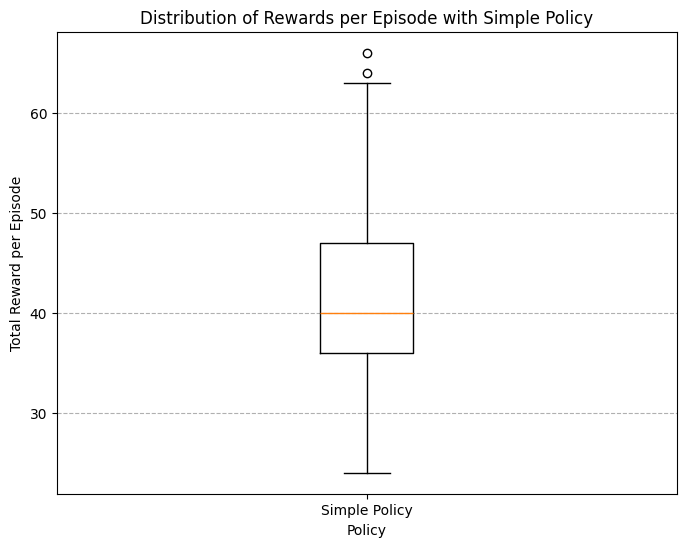

Mean reward over 1000 episodes: 41.46
Maximum reward over 1000 episodes: 66.00


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Number of episodes and timesteps
num_episodes = 1000
max_timesteps_per_episode = 1000

all_episode_rewards = []

print("Simulation for simple_policy:")

for episode in range(num_episodes):
    # env.reset returns (observation, info)
    observation, info = env.reset(seed=episode)
    episode_reward = 0
    terminated = False
    truncated = False

    for t in range(max_timesteps_per_episode):
        # Get action from simple_policy using the current observation array
        action = simple_policy(observation)

        # Take a step in the environment, and update the observation
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        if terminated or truncated:
            break

    all_episode_rewards.append(episode_reward)

print(f"Completed {num_episodes} episodes.")

# Boxplot of the rewards
plt.figure(figsize=(8, 6))
plt.boxplot(all_episode_rewards)
plt.title('Distribution of Rewards per Episode with Simple Policy')
plt.xlabel('Policy')
plt.ylabel('Total Reward per Episode')
plt.xticks([1], ['Simple Policy'])
plt.grid(axis='y', linestyle='--')
plt.show()

# Calculate mean and maximum reward
mean_reward = np.mean(all_episode_rewards)
max_reward = np.max(all_episode_rewards)
print(f"Mean reward over {num_episodes} episodes: {mean_reward:.2f}")
print(f"Maximum reward over {num_episodes} episodes: {max_reward:.2f}")


2b) **(POINTS: 1)** Is this policy able to solve the cart pole problem? Explain your answer.

No, because the average reward should be at least 195 over 100 consecutive trials, however, we see that the mean reward here us 41.46

#### 3) From Question [2], what is the mean and maximum reward (roughly)?
**(POINTS: 1)**

In [12]:
# From the execution of Question 2a:
# Mean reward over 1000 episodes: 41.46
# Maximum reward over 1000 episodes: 66.00

print(f"Mean reward: {np.mean(all_episode_rewards):.2f}")
print(f"Maximum reward: {np.max(all_episode_rewards):.2f}")

Mean reward: 41.46
Maximum reward: 66.00


#### 4) Reversed Simple Policy
**(POINTS: 2)**

What happens if you reverse the simple policy, moving left when the pole leans right, and moving right when the pole leans left? This is not a good idea, but it's instructive. To show the result, produce the boxplot from before, and calculate the mean reward.

Simulation for reversed_simple_policy:
Completed 1000 episodes with reversed policy.


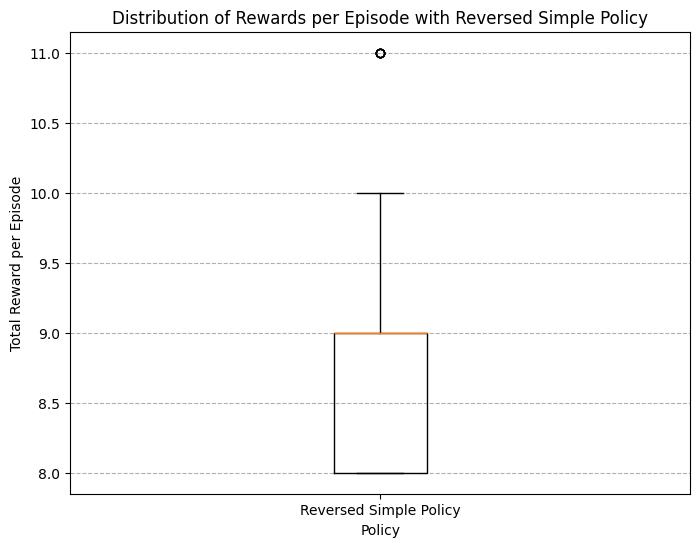

Mean reward over 1000 episodes with reversed policy: 8.74


In [13]:
def reversed_simple_policy(observation):
    pole_angle = observation[2]

    # Reversed policy
    if pole_angle < 0:
        return 1  # Move right
    else:
        return 0  # Move left


# Running the simulation with the reversed policy

all_episode_rewards_reversed = []

print("Simulation for reversed_simple_policy:")

for episode in range(num_episodes):
    observation, info = env.reset(seed=episode)
    episode_reward = 0
    terminated = False
    truncated = False

    for t in range(max_timesteps_per_episode):
        action = reversed_simple_policy(observation)
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        if terminated or truncated:
            break

    all_episode_rewards_reversed.append(episode_reward)

print(f"Completed {num_episodes} episodes with reversed policy.")

# Produce a boxplot of the rewards for the reversed policy
plt.figure(figsize=(8, 6))
plt.boxplot(all_episode_rewards_reversed)
plt.title('Distribution of Rewards per Episode with Reversed Simple Policy')
plt.xlabel('Policy')
plt.ylabel('Total Reward per Episode')
plt.xticks([1], ['Reversed Simple Policy'])
plt.grid(axis='y', linestyle='--')
plt.show()

# Calculate mean reward for the reversed policy
mean_reward_reversed = np.mean(all_episode_rewards_reversed)
print(f"Mean reward over {num_episodes} episodes with reversed policy: {mean_reward_reversed:.2f}")


#### 5) Modified Policy
**(POINTS: 2)** Full points for attempt and clear explanation.

Time to get creative! See if you can try a different policy that improves the mean reward. Clearly explain your strategy.

Simulation for modified_policy:
Completed 1000 episodes with modified policy.


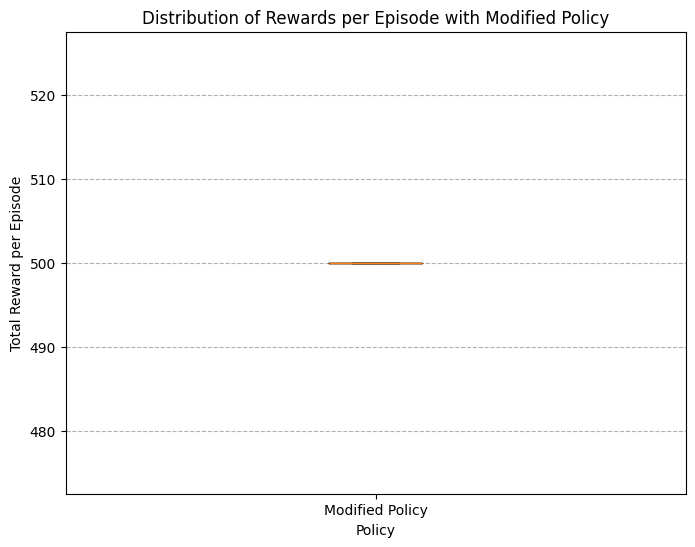

Mean reward over 1000 episodes with modified policy: 500.00


In [14]:
def modified_policy(observation):
    # Extract pole angle and angular velocity from the observation array
    pole_angle = observation[2]
    pole_angular_velocity = observation[3]
    epsilon = 0.05

    # IF we take the pole angle and angular velocity multiply by the geedy methods value of 0.05 to determine action
    # If the pole is leaning left (negative angle) and/or moving left (negative angular velocity),
    # move the cart to the left. Otherwise, we will move the cart to the right.
    # A small epsilon greedy methods (e.g., 0.5) can be used to weight the angular velocity.

    # If pole_angle is positive, it's leaning right.
    # If pole_angular_velocity is positive, it's rotating clockwise (moving from right to left).
    # If the sum is positive, the overall tendency is to fall right, so push right. Otherwise we are going counterclockwise.


    if pole_angle + (epsilon * pole_angular_velocity) < 0:
        return 0  # move left
    else:
        return 1  # move right


# Run the simulation with the modified policy
num_episodes = 1000
max_timesteps_per_episode = 1000

all_episode_rewards_modified = []

print("Simulation for modified_policy:")

for episode in range(num_episodes):
    observation, info = env.reset(seed=episode)
    episode_reward = 0
    terminated = False
    truncated = False

    for t in range(max_timesteps_per_episode):
        action = modified_policy(observation)
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        if terminated or truncated:
            break

    all_episode_rewards_modified.append(episode_reward)

print(f"Completed {num_episodes} episodes with modified policy.")

# Produce a boxplot of the rewards for the modified policy
plt.figure(figsize=(8, 6))
plt.boxplot(all_episode_rewards_modified)
plt.title('Distribution of Rewards per Episode with Modified Policy')
plt.xlabel('Policy')
plt.ylabel('Total Reward per Episode')
plt.xticks([1], ['Modified Policy'])
plt.grid(axis='y', linestyle='--')
plt.show()

# Calculate mean reward for the modified policy
mean_reward_modified = np.mean(all_episode_rewards_modified)
print(f"Mean reward over {num_episodes} episodes with modified policy: {mean_reward_modified:.2f}")


---  

### Wrapup

This demo illustrated some basic ideas of reinforcement learning and got you started with OpenAI Gym.

We will revisit this example later, bringing in more tools for a better solution.

---
